In [ ]:
from google.colab import files
uploaded = files.upload()   #  select historical_ridership.csv

Saving historical_ridership.csv to historical_ridership.csv


In [ ]:
import os
import warnings
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)

DATA_PATH = "historical_ridership.csv"
TARGET_COL = "total_rides"

WINDOW_SIZE = 30
TRAIN_SPLIT = 0.80
EPOCHS = 120
BATCH_SIZE = 32
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [ ]:
df = pd.read_csv(DATA_PATH)

for col in ["bus", "rail_boardings", "total_rides"]:
    df[col] = df[col].astype(str).str.replace(",", "").astype(float)

df["service_date"] = pd.to_datetime(df["service_date"], errors="coerce")

df.dropna(subset=["service_date", TARGET_COL], inplace=True)
df.sort_values("service_date", inplace=True)
df.set_index("service_date", inplace=True)

In [ ]:
# Calendar
df["day_of_week"] = df.index.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Cyclical encoding (VERY important)
df["sin_dow"] = np.sin(2*np.pi*df["day_of_week"]/7)
df["cos_dow"] = np.cos(2*np.pi*df["day_of_week"]/7)

# Day type encoding
day_type_map = {"W": 2, "A": 1, "U": 0}
df["day_type_enc"] = df["day_type"].map(day_type_map)

# Lags (most useful ones)
for lag in [1, 7, 14, 30]:
    df[f"lag_{lag}"] = df[TARGET_COL].shift(lag)

# Rolling mean
df["roll_mean_7"] = df[TARGET_COL].rolling(7).mean()

df.dropna(inplace=True)

In [ ]:
FEATURE_COLS = [
    "day_type_enc",
    "is_weekend",
    "sin_dow",
    "cos_dow",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "roll_mean_7"
]

In [ ]:
train_size = int(len(df) * TRAIN_SPLIT)

train_df = df.iloc[:train_size]
test_df  = df.iloc[train_size:]

In [ ]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaler_X.fit(train_df[FEATURE_COLS])
scaler_y.fit(train_df[[TARGET_COL]])

X_scaled = scaler_X.transform(df[FEATURE_COLS])
y_scaled = scaler_y.transform(df[[TARGET_COL]])

# Save scalers
with open("outputs/scaler_X.pkl", "wb") as f:
    pickle.dump(scaler_X, f)

with open("outputs/scaler_y.pkl", "wb") as f:
    pickle.dump(scaler_y, f)

In [ ]:
def create_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window]) #sliding window prob
        ys.append(y[i+window]) #takes the value right after the window
    return np.array(Xs), np.array(ys)

X, y = create_sequences(X_scaled, y_scaled, WINDOW_SIZE)

split_idx = int(len(X) * TRAIN_SPLIT)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [ ]:
model = Sequential([
    LSTM(128, return_sequences=True,
         input_shape=(WINDOW_SIZE, X.shape[2])),
    Dropout(0.2),

    LSTM(64), #this is the 2nd layer , goes on ahead the same way , dropping neurons too
    Dropout(0.2),

    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="mse",
    metrics=["mae"]
) #why adam ? fast convergence and works well for time series concept

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,177 (477.25 KB)

 Trainable params: 122,177 (477.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#callbacks->tools that monitor and adjust traingi automatically
callbacks = [
    EarlyStopping(patience=15, restore_best_weights=True),
    ReduceLROnPlateau(patience=7, factor=0.5) #whatever the LR is , it gets half further
]

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,#model will see dataset upto 120 times
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    shuffle=False,
    callbacks=callbacks #applies the above things in callbacks
)

Epoch 1/120
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - loss: 0.0623 - mae: 0.2005 - val_loss: 0.0651 - val_mae: 0.2250 - learning_rate: 0.0010
Epoch 2/120
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.0371 - mae: 0.1599 - val_loss: 0.0648 - val_mae: 0.2161 - learning_rate: 0.0010
Epoch 3/120
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 0.0312 - mae: 0.1422 - val_loss: 0.0714 - val_mae: 0.2234 - learning_rate: 0.0010
Epoch 4/120
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0295 - mae: 0.1367 - val_loss: 0.0704 - val_mae: 0.2191 - learning_rate: 0.0010
Epoch 5/120
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.0279 - mae: 0.1326 - val_loss: 0.0671 - val_mae: 0.2133 - learning_rate: 0.0010
Epoch 6/120
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss: 0.0256 - mae: 0.1263 - val_loss: 0.0764 - val_mae: 0.2241 - learning_rate: 0.0010
Epoch 7/120
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.0246 - mae: 0.1229 - val_loss: 0.0800 - val_mae: 0.2261 - learning_rate: 0.0010
Epoch 

In [ ]:
y_pred_scaled = model.predict(X_test)

# Correct inverse transform
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
accuracy = 100 - mape

print(f"MAE      : {mae:,.0f}")
print(f"RMSE     : {rmse:,.0f}")
print(f"MAPE     : {mape:.2f}%")
print(f"Accuracy : {accuracy:.2f}%")

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
MAE      : 405,618
RMSE     : 445,305
MAPE     : 64.20%
Accuracy : 35.80%


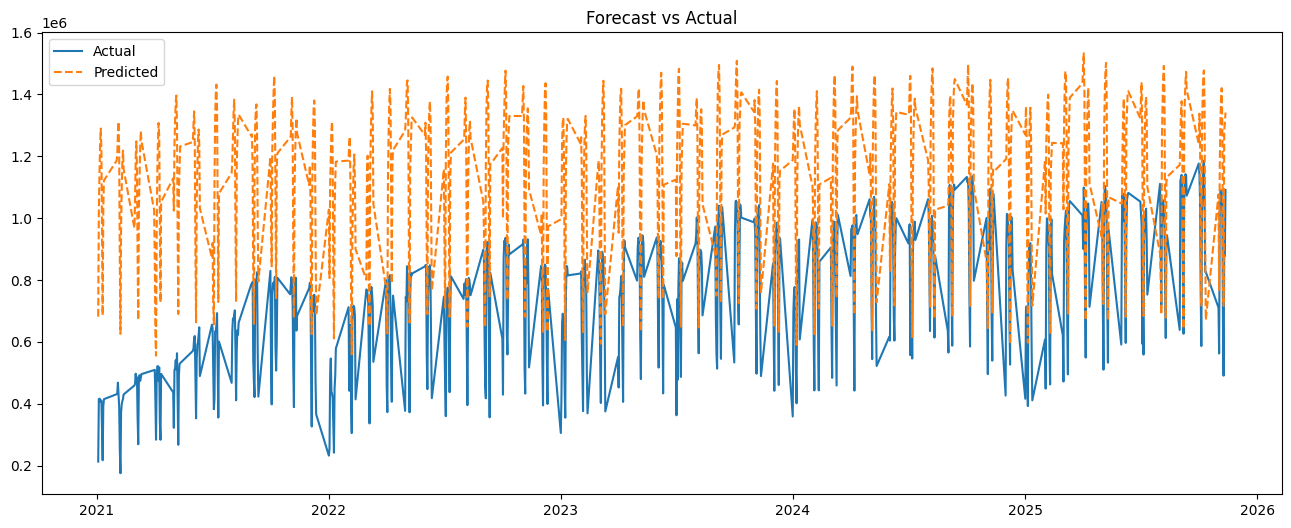

In [ ]:
dates = df.index[WINDOW_SIZE + split_idx:
                 WINDOW_SIZE + split_idx + len(y_true)]

plt.figure(figsize=(16,6))

plt.plot(dates, y_true, label="Actual")
plt.plot(dates, y_pred, "--", label="Predicted")

plt.legend()
plt.title("Forecast vs Actual")
plt.show()

In [ ]:
FORECAST_DAYS = 30

# Start from last known window
last_window = X_scaled[-WINDOW_SIZE:].copy()

future_preds_scaled = []

for _ in range(FORECAST_DAYS): #each iteration predicts one future day

    pred = model.predict(
        last_window.reshape(1, WINDOW_SIZE, X.shape[2]),
        verbose=0
    )[0, 0]

    future_preds_scaled.append(pred)

    # Update window with new prediction
    next_row = last_window[-1].copy()
    next_row[:] = next_row   # keep other features constant
    last_window = np.vstack([last_window[1:], next_row])

In [ ]:
future_preds = scaler_y.inverse_transform(
    np.array(future_preds_scaled).reshape(-1, 1)
).flatten()

future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1), #last day -- moves to next day
    periods=FORECAST_DAYS
)

future_df = pd.DataFrame({
    "date": future_dates,
    "predicted_rides": future_preds
})

print(future_df)

         date  predicted_rides
0  2025-11-13     1.327044e+06
1  2025-11-14     1.328334e+06
2  2025-11-15     1.330591e+06
3  2025-11-16     1.311087e+06
4  2025-11-17     1.254500e+06
5  2025-11-18     1.161012e+06
6  2025-11-19     1.078888e+06
7  2025-11-20     1.038449e+06
8  2025-11-21     1.032970e+06
9  2025-11-22     1.065364e+06
10 2025-11-23     1.117337e+06
11 2025-11-24     1.186391e+06
12 2025-11-25     1.262390e+06
13 2025-11-26     1.317952e+06
14 2025-11-27     1.345007e+06
15 2025-11-28     1.348802e+06
16 2025-11-29     1.336816e+06
17 2025-11-30     1.296430e+06
18 2025-12-01     1.247609e+06
19 2025-12-02     1.183530e+06
20 2025-12-03     1.132412e+06
21 2025-12-04     1.093228e+06
22 2025-12-05     1.076600e+06
23 2025-12-06     1.086538e+06
24 2025-12-07     1.115433e+06
25 2025-12-08     1.153334e+06
26 2025-12-09     1.183150e+06
27 2025-12-10     1.211094e+06
28 2025-12-11     1.231896e+06
29 2025-12-12     1.243368e+06


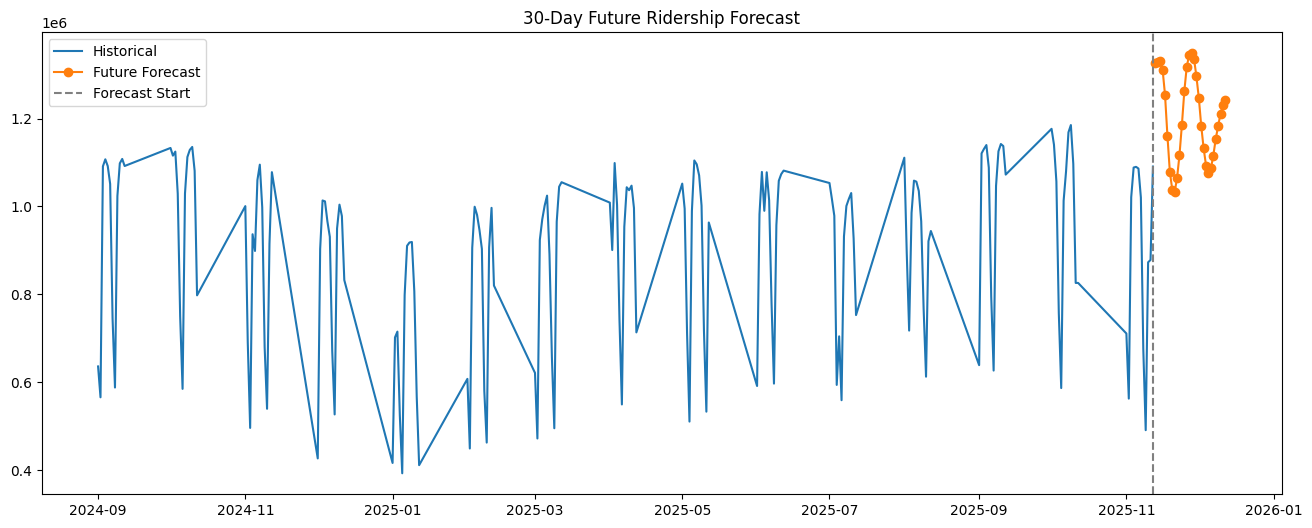

In [ ]:
plt.figure(figsize=(16,6))

# Show last 6 months of history
context = df[TARGET_COL].iloc[-180:]

plt.plot(context.index, context.values,
         label="Historical")

plt.plot(future_dates, future_preds,
         label="Future Forecast",
         marker="o")

plt.axvline(x=df.index[-1],
            linestyle="--",
            color="gray",
            label="Forecast Start")

plt.legend()
plt.title("30-Day Future Ridership Forecast")
plt.show()

In [ ]:
model.save("outputs/lstm_ridership_model.h5")

In [ ]:
future_df.to_csv("outputs/future_forecast_30days.csv", index=False)

In [ ]:
metrics = {
    "MAE": mae,
    "RMSE": rmse,
    "MAPE": mape,
    "Accuracy": accuracy
}

pd.DataFrame([metrics]).to_csv(
    "outputs/model_metrics.csv",
    index=False
)

In [ ]:
from google.colab import files
import os

# Download only PNG files from outputs folder
for file in os.listdir("outputs"):
    if file.endswith(".png"):
        files.download(os.path.join("outputs", file))

In [ ]:

# ==============================
# 📦 Imports
# ==============================
import os
import warnings
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)

# ==============================
# ⚙️ Config
# ==============================
DATA_PATH = "forecast.csv"
TARGET_COL = "Close"

WINDOW_SIZE = 30
TRAIN_SPLIT = 0.80
EPOCHS = 100
BATCH_SIZE = 32
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ==============================
# 📊 Load Data
# ==============================
df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df.dropna(subset=["Date", TARGET_COL], inplace=True)

df.sort_values("Date", inplace=True)
df.set_index("Date", inplace=True)

# ==============================
# 🧠 Feature Engineering
# ==============================

# Time features
df["day_of_week"] = df.index.dayofweek
df["sin_dow"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["cos_dow"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

# Returns
df["return"] = df["Close"].pct_change()

# Lag features
for lag in [1, 3, 7, 14]:
    df[f"lag_{lag}"] = df[TARGET_COL].shift(lag)

# Rolling features
df["roll_mean_7"] = df[TARGET_COL].rolling(7).mean()
df["roll_std_7"] = df[TARGET_COL].rolling(7).std()

df.dropna(inplace=True)

# ==============================
# 🎯 Features
# ==============================
FEATURE_COLS = [
    "Open",
    "High",
    "Low",
    "Volume",
    "sin_dow",
    "cos_dow",
    "return",
    "lag_1",
    "lag_3",
    "lag_7",
    "lag_14",
    "roll_mean_7",
    "roll_std_7"
]

# ==============================
# 🔀 Train-Test Split
# ==============================
train_size = int(len(df) * TRAIN_SPLIT)

train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

# ==============================
# 🔄 Scaling
# ==============================
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaler_X.fit(train_df[FEATURE_COLS])
scaler_y.fit(train_df[[TARGET_COL]])

X_scaled = scaler_X.transform(df[FEATURE_COLS])
y_scaled = scaler_y.transform(df[[TARGET_COL]])

# Save scalers
with open("outputs/scaler_X.pkl", "wb") as f:
    pickle.dump(scaler_X, f)

with open("outputs/scaler_y.pkl", "wb") as f:
    pickle.dump(scaler_y, f)

# ==============================
# 🔁 Sequence Creation
# ==============================
def create_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)

X, y = create_sequences(X_scaled, y_scaled, WINDOW_SIZE)

split_idx = int(len(X) * TRAIN_SPLIT)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# ==============================
# 🤖 Model
# ==============================
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(WINDOW_SIZE, X.shape[2])),
    Dropout(0.2),

    LSTM(64),
    Dropout(0.2),

    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="mse",
    metrics=["mae"]
)

model.summary()

# ==============================
# 🧠 Training
# ==============================
callbacks = [
    EarlyStopping(patience=15, restore_best_weights=True),
    ReduceLROnPlateau(patience=7, factor=0.5)
]

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    shuffle=False,
    callbacks=callbacks
)

# ==============================
# 📈 Evaluation
# ==============================
y_pred_scaled = model.predict(X_test)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
accuracy = 100 - mape

print(f"MAE      : {mae:.2f}")
print(f"RMSE     : {rmse:.2f}")
print(f"MAPE     : {mape:.2f}%")
print(f"Accuracy : {accuracy:.2f}%")

# ==============================
# 📊 Plot Predictions
# ==============================
dates = df.index[WINDOW_SIZE + split_idx:
                 WINDOW_SIZE + split_idx + len(y_true)]

plt.figure(figsize=(14,6))
plt.plot(dates, y_true, label="Actual")
plt.plot(dates, y_pred, "--", label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Prices")
plt.show()

# ==============================
# 🔮 Future Forecast
# ==============================
FORECAST_DAYS = 30

last_window = X_scaled[-WINDOW_SIZE:].copy()
future_preds_scaled = []

for _ in range(FORECAST_DAYS):

    pred = model.predict(
        last_window.reshape(1, WINDOW_SIZE, X.shape[2]),
        verbose=0
    )[0, 0]

    future_preds_scaled.append(pred)

    next_row = last_window[-1].copy()

    # Update lag feature (important)
    next_row[FEATURE_COLS.index("lag_1")] = pred

    last_window = np.vstack([last_window[1:], next_row])

future_preds = scaler_y.inverse_transform(
    np.array(future_preds_scaled).reshape(-1, 1)
).flatten()

future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=FORECAST_DAYS
)

# ==============================
# 📊 Future Plot
# ==============================
plt.figure(figsize=(14,6))

plt.plot(df.index[-180:], df[TARGET_COL].iloc[-180:], label="History")
plt.plot(future_dates, future_preds, marker="o", label="Forecast")

plt.axvline(x=df.index[-1], linestyle="--", color="gray")

plt.legend()
plt.title("30-Day Stock Forecast")
plt.show()

# ==============================
# 💾 Save Outputs
# ==============================
model.save("outputs/lstm_stock_model.h5")

pd.DataFrame({
    "Date": future_dates,
    "Predicted_Close": future_preds
}).to_csv("outputs/future_predictions.csv", index=False)

pd.DataFrame([{
    "MAE": mae,
    "RMSE": rmse,
    "MAPE": mape,
    "Accuracy": accuracy
}]).to_csv("outputs/model_metrics.csv", index=False)

print("✅ Model + predictions saved in outputs/")